Saved: E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\figures\test_polar_plots_norm-per-tissue-sample.svg


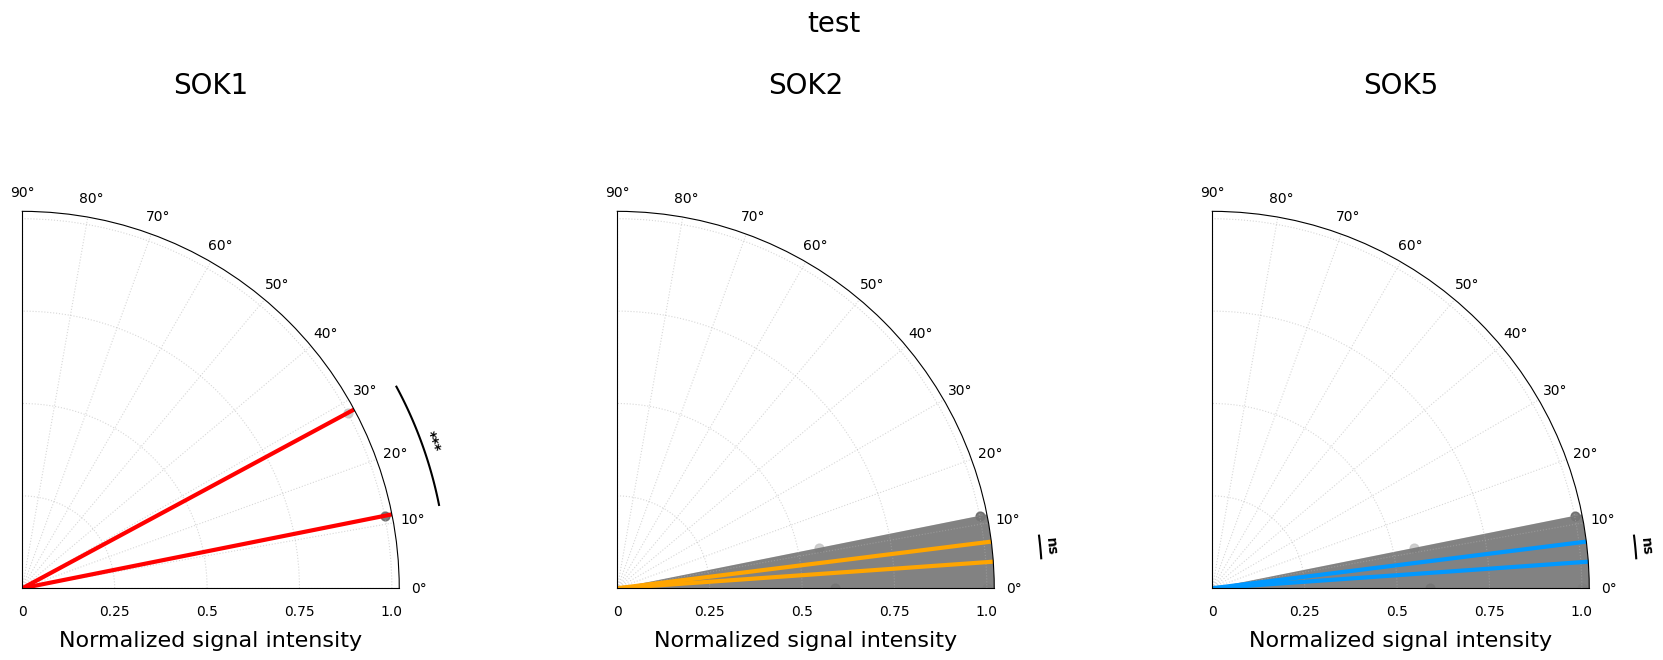

Saved: E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\figures\young_LRP_polar_plots_norm-per-tissue-sample.svg


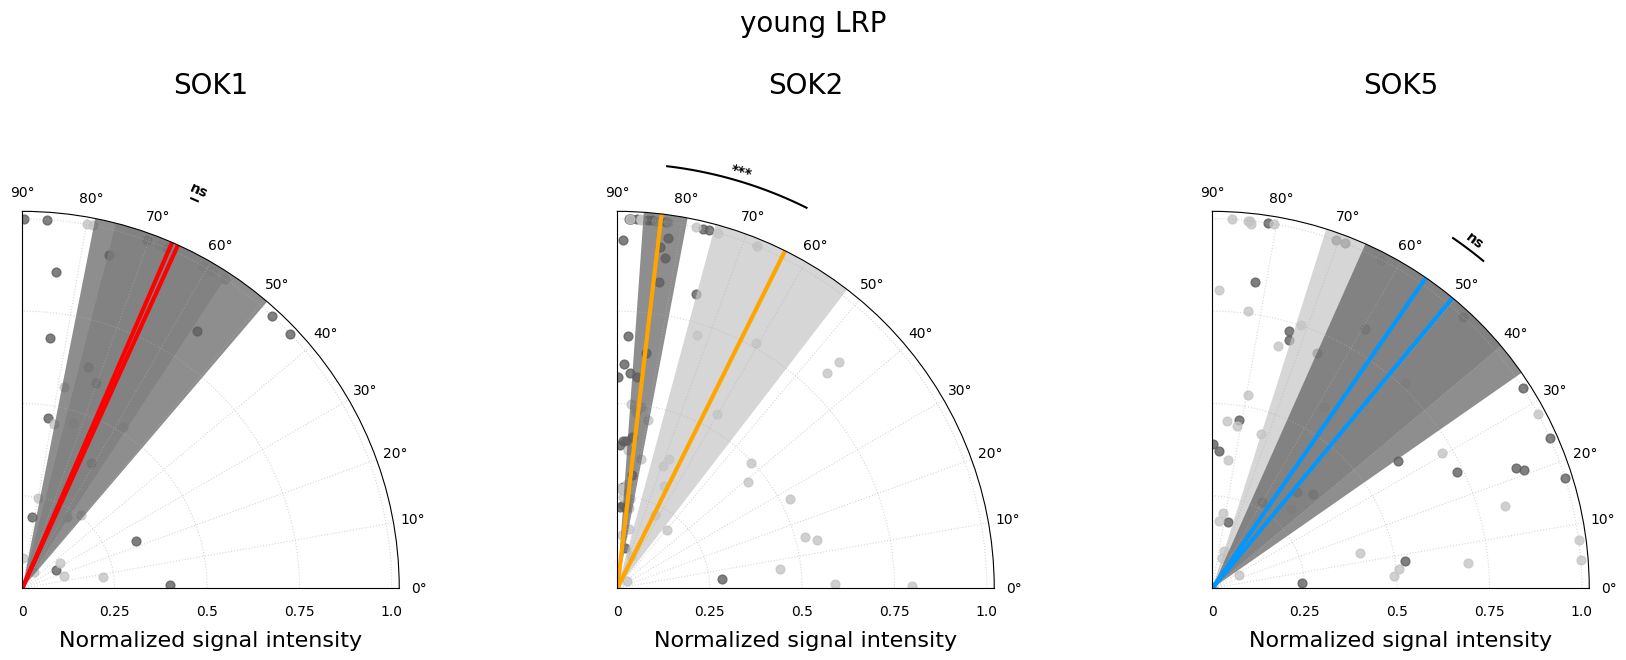

Saved: E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\figures\young_emerged_polar_plots_norm-per-tissue-sample.svg


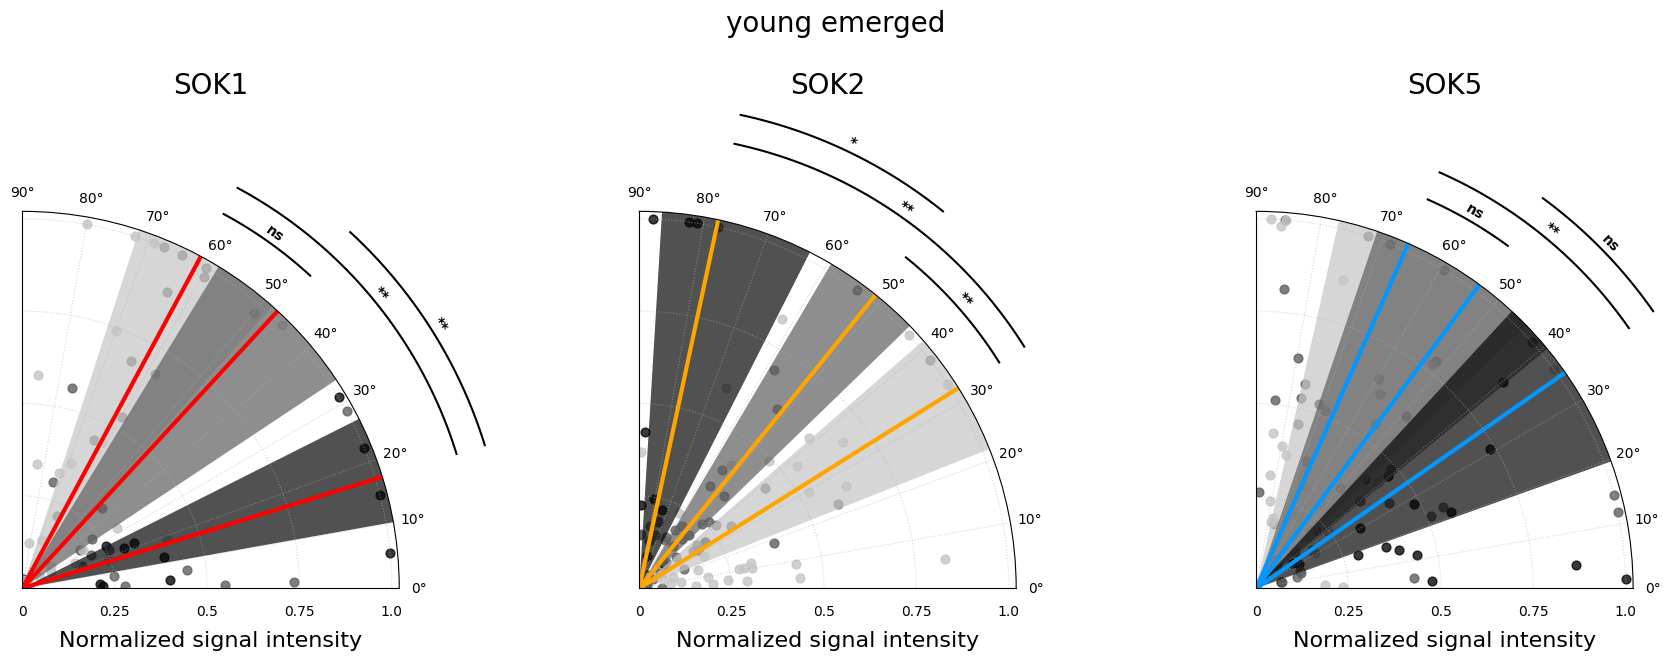

Saved: E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\figures\mature_roots_polar_plots_norm-per-tissue-sample.svg


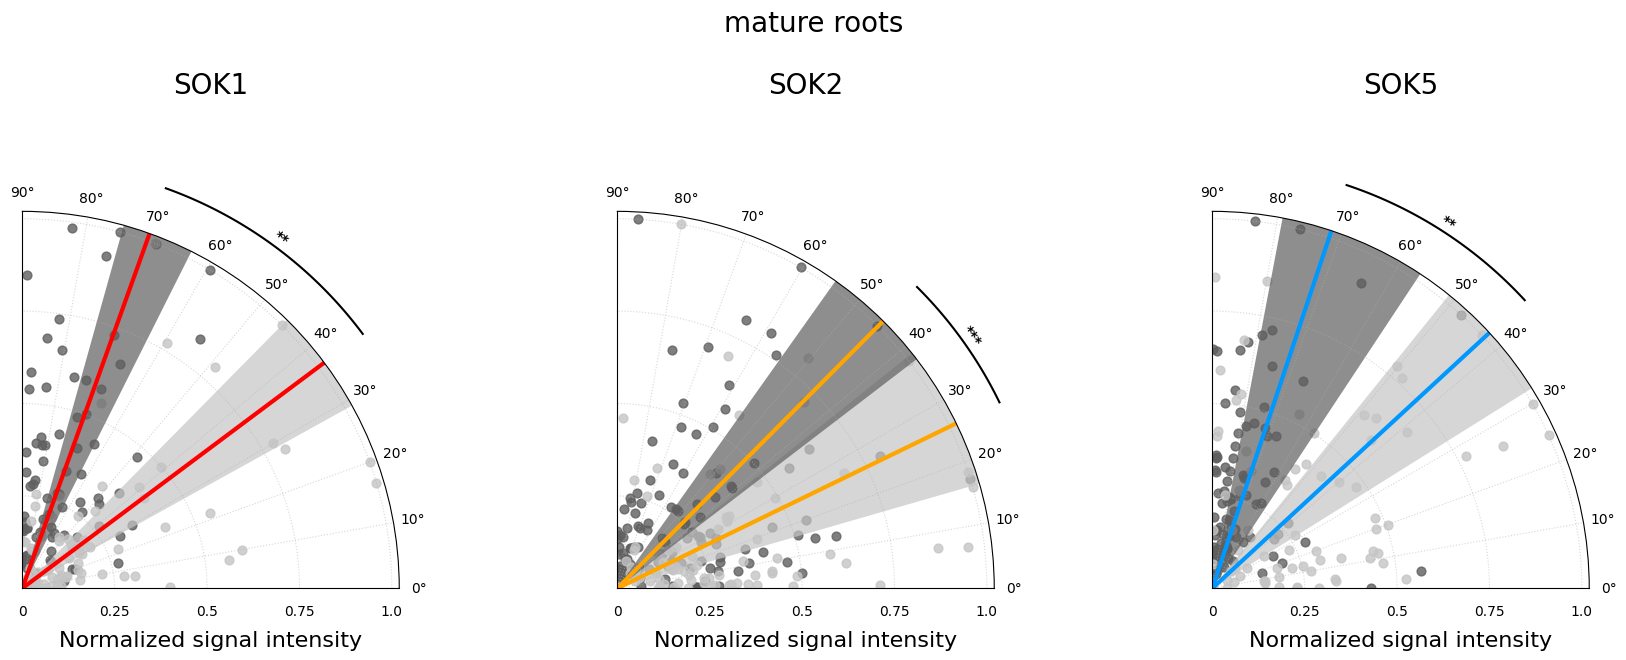

In [14]:
# Combined polar plots for SOK1, SOK2, and SOK5
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sok_base = Path(r"E:\Work\\SOKs\\TIFFS_publication\\Fig SX_emergence-cellular\\polarisation\\script")
sok_list = ['SOK1', 'SOK2', 'SOK5']
# Minimal color palette (matches earlier cells)
colors = {'A': "#070707", 'G': "#5F5F5F", 'V': "#c5c5c5"}

# Helper for bootstrap and significance annotation
from itertools import combinations

# 1. UPDATED: Hierarchical Bootstrap Function
def bootstrap_hierarchical_weighted_means(df, n_boot=2000):
    roots = df['source_file'].unique()
    n_roots = len(roots)
    boot_means = np.empty(n_boot)
    
    for i in range(n_boot):
        # 1. Sample roots with replacement
        sampled_roots = np.random.choice(roots, size=n_roots, replace=True)
        
        # 2. Collect cells from sampled roots
        resampled_data = []
        for root in sampled_roots:
            root_data = df[df['source_file'] == root]
            idx = np.random.choice(len(root_data), size=len(root_data), replace=True)
            resampled_data.append(root_data.iloc[idx])
        
        # 3. Calculate weighted mean for this bootstrap iteration
        combined = pd.concat(resampled_data)
        angles = combined['deviation_degrees'].values
        weights = combined['r'].values
        boot_means[i] = np.average(angles, weights=weights) if weights.sum() > 0 else np.mean(angles)
    return boot_means

def bootstrap_hierarchical_weighted_diffs(df, tissue_a, tissue_b, n_boot=2000):
    roots_a = set(df.loc[df['Tissue'] == tissue_a, 'source_file'].unique())
    roots_b = set(df.loc[df['Tissue'] == tissue_b, 'source_file'].unique())
    common_roots = sorted(roots_a.intersection(roots_b))
    if not common_roots:
        return np.array([])

    n_roots = len(common_roots)
    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):
        sampled_roots = np.random.choice(common_roots, size=n_roots, replace=True)
        resampled_a = []
        resampled_b = []

        for root in sampled_roots:
            root_a = df[(df['source_file'] == root) & (df['Tissue'] == tissue_a)]
            root_b = df[(df['source_file'] == root) & (df['Tissue'] == tissue_b)]
            if root_a.empty or root_b.empty:
                continue

            idx_a = np.random.choice(len(root_a), size=len(root_a), replace=True)
            idx_b = np.random.choice(len(root_b), size=len(root_b), replace=True)
            resampled_a.append(root_a.iloc[idx_a])
            resampled_b.append(root_b.iloc[idx_b])

        if not resampled_a or not resampled_b:
            boot_diffs[i] = np.nan
            continue

        combined_a = pd.concat(resampled_a)
        combined_b = pd.concat(resampled_b)

        mean_a = np.average(combined_a['deviation_degrees'], weights=combined_a['r']) if combined_a['r'].sum() > 0 else np.mean(combined_a['deviation_degrees'])
        mean_b = np.average(combined_b['deviation_degrees'], weights=combined_b['r']) if combined_b['r'].sum() > 0 else np.mean(combined_b['deviation_degrees'])
        boot_diffs[i] = mean_a - mean_b

    return boot_diffs[~np.isnan(boot_diffs)]
      
def p_value_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'ns'


def get_weighted_stats(df, n_boot=5000):
    angles = df['deviation_degrees'].values
    weights = df['r'].values
    if len(angles) == 0:
        return 0, 0, 0
    probs = weights / weights.sum() if weights.sum() > 0 else np.ones_like(weights) / len(weights)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.choice(len(angles), size=len(angles), replace=True, p=probs)
        boot_means[i] = np.mean(angles[idx])

    mean_val = np.average(angles, weights=weights) if weights.sum() > 0 else np.mean(angles)
    ci = np.percentile(boot_means, [2.5, 97.5])
    return mean_val, ci[0], ci[1]

plot_folders = ["test", "young LRP", "young emerged", "mature roots"]
mean_line_colors = {'SOK1': 'red', 'SOK2': 'orange', 'SOK5': '#0098ff'}
ci_r_max = 1.02

tissue_order = ['V', 'G', 'A']

for plot_folder in plot_folders:
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'polar'})
    fig.suptitle(plot_folder, fontsize=20, y=1.05)

    for ax, sok in zip(axs, sok_list):
        sok_folder = sok_base / sok
        csv_folder = sok_folder / plot_folder
        if not csv_folder.exists():
            print(f"No folder {csv_folder} for {sok}")
            ax.set_visible(False)
            continue

        # Load and Filter Data
        polarisation_files = sorted(csv_folder.glob("polarisation*.csv"))
        if not polarisation_files:
            ax.set_visible(False); continue
            
        polar_df = pd.concat((pd.read_csv(f).assign(source_file=f.name) for f in polarisation_files), ignore_index=True)
        
        # --- UPDATED FILTERING LOGIC ---
        if plot_folder == "young emerged":
            # Show all three tissues (V, G, A) for this specific folder
            polar_df = polar_df[polar_df['Tissue'].isin(['V', 'G', 'A'])].copy()
            current_order = ['V', 'G', 'A']
            if 'Specific tissue' in polar_df.columns:
                polar_df = polar_df[polar_df['Specific tissue'] != 'E'].copy()
        else:
            # Standard filtering for others
            polar_df = polar_df[polar_df['Tissue'].isin(['G', 'V'])].copy()
            current_order = ['V', 'G', 'A']
            if 'Specific tissue' in polar_df.columns:
                    polar_df = polar_df[polar_df['Specific tissue'] != 'E'].copy()
        # -------------------------------
            
        if polar_df.empty: 
            ax.set_visible(False); continue

        polar_df['deviation_degrees'] = np.degrees(np.arctan2(np.abs(polar_df['yMax']), np.abs(polar_df['xMax'])))
        polar_df['theta'] = np.radians(polar_df['deviation_degrees'])
        polar_df['r'] = polar_df.groupby(['source_file', 'Tissue'])['signalMax'].transform(
            lambda x: x / x.max() if x.max() != 0 else 0
        )

        for tissue, group in polar_df.groupby('Tissue'):
            ax.scatter(group['theta'], group['r'], c=colors.get(tissue, '#000000'), label=f"Tissue {tissue}", alpha=0.8, s=40)

        weighted_means = polar_df.groupby('Tissue').apply(lambda g: np.average(g['deviation_degrees'], weights=g['r']) if g['r'].sum() > 0 else np.mean(g['deviation_degrees'])).reset_index(name='mean_acute_angle')
        present_tissues = [t for t in tissue_order if t in weighted_means['Tissue'].values]
        cis_local = {}
        bootstrap_reps = {}
        for tissue, group in polar_df.groupby('Tissue'):
            boot = bootstrap_hierarchical_weighted_means(group, n_boot=2000)
            mean = np.average(group['deviation_degrees'], weights=group['r']) if group['r'].sum() > 0 else np.mean(group['deviation_degrees'])
            if len(boot):
                lo, hi = np.percentile(boot, [2.5, 97.5])
            else:
                _, lo, hi = get_weighted_stats(group, n_boot=2000)
            cis_local[tissue] = (lo, hi)
            bootstrap_reps[tissue] = boot
        weighted_means['ci_lo'] = weighted_means['Tissue'].map(lambda t: cis_local[t][0])
        weighted_means['ci_hi'] = weighted_means['Tissue'].map(lambda t: cis_local[t][1])
        
        pairwise_results = []
        # Get all possible combinations (e.g., V-G, V-A, G-A)
        combos = list(combinations(present_tissues, 2))
        num_comparisons = len(combos)
        
        for a, b in combos:
            diffs = bootstrap_hierarchical_weighted_diffs(polar_df, a, b, n_boot=2000)
            if len(diffs):
                tail_ge = (np.sum(diffs >= 0) + 1) / (len(diffs) + 1)
                tail_le = (np.sum(diffs <= 0) + 1) / (len(diffs) + 1)
                p_raw = min(2 * min(tail_ge, tail_le), 1.0)
                
                # Apply Bonferroni correction
                p_adjusted = min(p_raw * num_comparisons, 1.0)
                
                pairwise_results.append((a, b, p_adjusted))

        mean_angle_map = {}
        for tissue in present_tissues:
            mean_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'mean_acute_angle'].iloc[0])
            lo_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_lo'].iloc[0])
            hi_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_hi'].iloc[0])

            mean_angle_map[tissue] = mean_angle
            theta_mean = np.radians(mean_angle)
            theta_lo = np.radians(lo_angle)
            theta_hi = np.radians(hi_angle)
            ci_color = colors.get(tissue, '#000000')
            mean_color = mean_line_colors.get(sok, '#000000')

            width = theta_hi - theta_lo
            if width < 0:
                width += 2 * np.pi
            ax.bar((theta_lo + width/2), ci_r_max, width=width, bottom=0.0,
                   color=ci_color, alpha=0.7, edgecolor='none', align='center')
            ax.plot([theta_mean, theta_mean], [0, ci_r_max], color=mean_color, linewidth=3, solid_capstyle='butt')

        outer_offset = 0.13
        line_gap = 0.08
        for idx, (a, b, p_boot) in enumerate(pairwise_results):
            if a not in mean_angle_map or b not in mean_angle_map:
                continue
            theta_a = np.radians(mean_angle_map[a])
            theta_b = np.radians(mean_angle_map[b])
            theta_start, theta_end = sorted([theta_a, theta_b])
            arc_r = ci_r_max + outer_offset + idx * line_gap
            arc_theta = np.linspace(theta_start, theta_end, 120)
            ax.plot(arc_theta, np.full_like(arc_theta, arc_r), color='black', lw=1.5, clip_on=False)
            mid_theta = (theta_start + theta_end) / 2
            rotation_angle = np.degrees(mid_theta) + 90
            if rotation_angle > 90:
                rotation_angle -= 180
            ax.text(mid_theta, arc_r + 0.01,
                    p_value_to_stars(p_boot), ha='center', va='bottom', fontsize=10,
                    fontweight='bold', clip_on=False, rotation=rotation_angle, rotation_mode='anchor')

        ax.set_thetamin(0)
        ax.set_thetamax(90)
        ax.set_theta_zero_location("E")
        ax.set_theta_direction(1)
        ax.set_ylim(0, 1.02)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=10)
        ax.tick_params(axis='y', pad=8)
        ax.set_xlabel('Normalized signal intensity', fontsize=16, labelpad=25)
        ax.set_title(f"{sok}", fontsize=20, pad=85)
        ax.grid(True, linestyle=':', alpha=0.5)

    output_dir = sok_base / "figures"
    output_dir.mkdir(exist_ok=True)

    filename = output_dir / f"{plot_folder.replace(' ', '_')}_polar_plots_norm-per-tissue-sample.svg"
    plt.savefig(filename, format='svg', bbox_inches='tight')
    print(f"Saved: {filename}")

    plt.tight_layout()
    plt.show()


In [11]:
# Run the helper script that computes replicate-level summaries and prints results
exec(open(r'e:\\Work\\SOKs\\TIFFS_publication\\Fig SX_emergence-cellular\\polarisation\\script\\compute_replicate_stats.py').read())



=== SOK1 — found 6 polarisation files ===
Replicates per tissue:
Tissue
G    6
V    6
Tissue means and bootstrap CIs (replicates):
  G: mean=64.924, CI=(50.575, 78.786)
  V: mean=66.769, CI=(59.206, 74.331)
Pairwise tests (permutations and Welch t-test):
  G vs V: n=6,6; p_perm=0.8572; p_t=0.8466


c:\Users\mjcpi\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\mjcpi\miniconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(



Mixed-effects model summary:
          Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  rep_mean
No. Observations:   12       Method:              ML      
No. Groups:         6        Scale:               211.2784
Min. group size:    2        Log-Likelihood:      -49.1882
Max. group size:    2        Converged:           Yes     
Mean group size:    2.0                                   
----------------------------------------------------------
               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------
Intercept      64.924    5.955 10.903 0.000  53.253 76.595
C(Tissue)[T.V]  1.845    8.392  0.220 0.826 -14.603 18.293
Group Var       1.484    8.607                            


=== SOK2 — found 11 polarisation files ===
Replicates per tissue:
Tissue
G    9
V    9
Tissue means and bootstrap CIs (replicates):
  G: mean=82.750, CI=(79.993, 85.405)
  V: mean=66.834, CI=(58.383, 75.620)
Pair